In [35]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator, PercentFormatter
from sklearn.model_selection import KFold, GroupKFold

# colab setup
try:
    from google.colab import drive, files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# mount fail try and except
if IN_COLAB:
    try:
        drive.mount('/content/drive')
    except Exception as e:
        print('drive mount failed:', e)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
NEEDED = ['alpharetta_parcels.csv', 'alpharetta_structures.csv', 'alpharetta_supplement.csv',
          'alpharetta_sales.csv', 'forsyth_parcels.csv']

# data storage
FOLDERS = ['/content/drive/MyDrive/housing_price_project_v2',
           '/content/drive/MyDrive/housing_price_project',
           '/content/housing_data',
           '/content']


# folder with all 5 files
def find_data_dir():
    for folder in FOLDERS:
        folder = Path(folder)
        if all((folder / f).exists() for f in NEEDED):
            return folder
    return None


DATA_DIR = find_data_dir()

# upload non-drive files
if DATA_DIR is None and IN_COLAB:
    print('upload these:', NEEDED)
    files.upload()
    DATA_DIR = find_data_dir()

if DATA_DIR is None:
    raise FileNotFoundError(f'need these in one folder: {NEEDED}')

OUT_DIR = DATA_DIR / 'output'
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('data from', DATA_DIR)

# settings for every model
PARAMS = dict(n_estimators=600, learning_rate=0.06, num_leaves=48, min_child_samples=15,
              subsample=0.8, subsample_freq=1, colsample_bytree=0.8, verbose=-1, random_state=42)

data from /content/drive/MyDrive/housing_price_project_v2


In [1]:
# columns
def make_X(df, cols, cats):
    X = df[cols].copy()
    for c in cols:
        if c in cats:
            X[c] = X[c].astype('category')
    return X


def oof_predict(X, y, splitter, groups=None):
    preds = np.zeros(len(X))
    for train, test in splitter.split(X, y, groups):
        model = lgb.LGBMRegressor(**PARAMS)
        model.fit(X.iloc[train], y.iloc[train])
        preds[test] = model.predict(X.iloc[test])
    return preds


def summarize(pred, actual):
    err = pred - actual
    ape = np.abs(err) / actual
    r2 = 1 - np.sum(err ** 2) / np.sum((actual - actual.mean()) ** 2)
    return {'R2': round(float(r2), 3),
            'MAE $': int(np.abs(err).mean()),
            'MAPE %': round(float(ape.mean() * 100), 2),
            'median APE %': round(float(np.median(ape) * 100), 2),
            'within 10% of county value': round(float((ape <= 0.10).mean() * 100), 1)}


# 80% band from errors
def make_interval(resid):
    lo, hi = np.quantile(resid, [0.10, 0.90])
    return float(lo), float(hi)


# make the band on half the errors
# test it on the other half
def split_half_coverage(resid):
    idx = np.random.default_rng(0).permutation(len(resid))
    half = len(idx) // 2
    first = resid[idx[:half]]
    second = resid[idx[half:]]
    lo, hi = np.quantile(first, [0.10, 0.90])
    inside = (second >= lo) & (second <= hi)
    return round(float(inside.mean()), 3)


TIERS = ['lowest 20%', '20-40%', '40-60%', '60-80%', 'top 20%']


# in band per price tier
def coverage_by_tier(actual, low, high):
    inside = pd.Series((actual >= low) & (actual <= high))
    tier = pd.qcut(actual, 5, labels=TIERS)
    return inside.groupby(tier, observed=True).mean().round(3)


# column pushed each estimate
def contributions(model, X):
    c = model.predict(X, pred_contrib=True)
    return pd.DataFrame(c[:, :-1], columns=X.columns, index=X.index)

In [38]:
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (8, 4.5),
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.titleweight': 'bold',
                     'axes.titlesize': 12, 'axes.labelsize': 10})

# color scheme
COLOR = {'alpharetta': '#2f6690', 'forsyth': '#c0612b'}
CMAP = {'alpharetta': 'Blues', 'forsyth': 'Oranges'}


# money format
def fmt_money(v, pos=None):
    if abs(v) >= 1e6:
        return f'${v / 1e6:.1f}M'
    return f'${v / 1e3:.0f}k'


money = FuncFormatter(fmt_money)


# save as png
def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'{name}.png', bbox_inches='tight')
    plt.show()
    plt.close(fig)


def plot_value_hist(ax, values, market):
    bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 60)
    ax.hist(values, bins=bins, color=COLOR[market], alpha=0.85)
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(money)
    med = np.median(values)
    ax.axvline(med, color='black', ls='--', lw=1)
    ax.text(med, ax.get_ylim()[1] * 0.92, ' median ' + fmt_money(med), fontsize=9)
    ax.set_xlabel('county value (log scale)')
    ax.set_ylabel('homes')


# diverging=True is for errors
# red too high blue too low
def plot_map(ax, lon, lat, values, title, label, diverging=False):
    ok = np.isfinite(lon) & np.isfinite(lat)
    lon, lat, values = lon[ok], lat[ok], values[ok]
    if diverging:
        lim = np.nanpercentile(np.abs(values), 95)
        sc = ax.scatter(lon, lat, c=values, s=3, cmap='RdBu_r', vmin=-lim, vmax=lim)
        plt.colorbar(sc, ax=ax, shrink=0.8, label=label)
    else:
        # log colors to make it look diff
        sc = ax.scatter(lon, lat, c=np.log10(values), s=3, cmap='viridis')
        cb = plt.colorbar(sc, ax=ax, shrink=0.8, label=label)
        lo, hi = sc.get_clim()
        ticks = []
        for v in [5e4, 1e5, 2e5, 3e5, 5e5, 1e6, 2e6, 5e6]:
            if lo <= np.log10(v) <= hi:
                ticks.append(np.log10(v))
        cb.set_ticks(ticks)
        cb.set_ticklabels([fmt_money(10 ** t) for t in ticks])
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.set_aspect(1 / np.cos(np.deg2rad(np.mean(lat))))
    ax.set_title(title)
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')
    ax.grid(False)


# dashed lines are +-10%
def plot_pred_vs_actual(ax, actual, pred, market, title):
    hb = ax.hexbin(actual, pred, gridsize=60, xscale='log', yscale='log', bins='log',
                   cmap=CMAP[market], mincnt=1)
    lo = min(actual.min(), pred.min())
    hi = max(actual.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], color='black', lw=1)
    for k in [1.1, 0.9]:
        ax.plot([lo, hi], [lo * k, hi * k], color='gray', lw=0.8, ls='--')
    ax.xaxis.set_major_formatter(money)
    ax.yaxis.set_major_formatter(money)
    ax.set_xlabel('county value')
    ax.set_ylabel('model estimate')
    ax.set_title(title)
    plt.colorbar(hb, ax=ax, label='homes (log)')


def plot_residuals(ax, resid, lo, hi, market):
    # log error to % error
    pct = (np.exp(resid) - 1) * 100
    ax.hist(np.clip(pct, -60, 60), bins=80, color=COLOR[market], alpha=0.85)
    ax.axvspan((np.exp(lo) - 1) * 100, (np.exp(hi) - 1) * 100, color='gray', alpha=0.15, label='80% band')
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('county value vs estimate (%), positive = model too low')
    ax.set_ylabel('homes')
    ax.legend()


def plot_error_by_tier(ax, actual, pred, market):
    pct = (pred - actual) / actual * 100
    tier = pd.qcut(actual, 5, labels=TIERS)
    data = [pct[tier == t] for t in TIERS]
    bp = ax.boxplot(data, showfliers=False, patch_artist=True, widths=0.6)
    for box in bp['boxes']:
        box.set_facecolor(COLOR[market])
        box.set_alpha(0.6)
    ax.set_xticks(range(1, 6), TIERS)
    ax.axhline(0, color='black', lw=1)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.set_xlabel('price tier (by county value)')
    ax.set_ylabel('estimate error')


def plot_coverage(ax, cov, market):
    ax.bar(cov.index.astype(str), cov.values, color=COLOR[market], alpha=0.8)
    ax.axhline(0.8, color='black', ls='--', lw=1, label='target 80%')
    for i, v in enumerate(cov.values):
        ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=9)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylabel('county value inside the band')
    ax.set_xlabel('price tier')
    ax.legend(loc='lower right')


def plot_importance(ax, model, market, top=15):
    imp = pd.Series(model.booster_.feature_importance('gain'), index=model.booster_.feature_name())
    imp = (imp / imp.sum()).sort_values().tail(top)
    ax.barh(imp.index, imp.values, color=COLOR[market], alpha=0.85)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel('share of total split gain')


def plot_mean_contrib(ax, contrib, market, top=15):
    m = contrib.abs().mean().sort_values().tail(top)
    # log units to rough %
    m = (np.exp(m) - 1) * 100
    ax.barh(m.index, m.values, color=COLOR[market], alpha=0.85)
    ax.set_xlabel('average effect on the estimate (%)')


def plot_dependence(ax, x, contrib_col, market, xlabel):
    ok = x.notna()
    ax.scatter(x[ok], (np.exp(contrib_col[ok]) - 1) * 100, s=3, alpha=0.3, color=COLOR[market])
    ax.axhline(0, color='black', lw=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('effect on estimate (%)')

In [39]:
# alpharetta parcels from the fulton assessor
parcels = pd.read_csv(DATA_DIR / 'alpharetta_parcels.csv',
                      dtype={'ParcelID': str, 'NbrHood': str, 'LUCode': str, 'Subdiv': str})
parcels['ParcelID'] = parcels['ParcelID'].str.strip()

# buildings
struct = pd.read_csv(DATA_DIR / 'alpharetta_structures.csv', dtype=str)
struct['ParcelID'] = struct['ParcelID'].str.strip()
num_cols = ['Card', 'YrBlt', 'Stories', 'FinBsmtVal', 'AreaSF', 'TotRooms', 'TotBed', 'FixBath',
            'FixHalf', 'Firepl_S', 'Firepl_PF']
for c in num_cols:
    struct[c] = pd.to_numeric(struct[c], errors='coerce')

# card has to be a number
struct = struct.sort_values(['ParcelID', 'Card'])

# sqft added up over all cards
per_parcel = struct.groupby('ParcelID').agg(AreaSF_all=('AreaSF', 'sum'), n_cards=('Card', 'nunique'))

# everything else from card 1
main_cols = ['YrBlt', 'Stories', 'Basement', 'FinBsmtVal', 'ExtWall', 'Attic', 'TotRooms', 'TotBed',
             'FixBath', 'FixHalf', 'Firepl_S', 'Firepl_PF']
main = struct.drop_duplicates('ParcelID').set_index('ParcelID')[main_cols]

# frontage and topo
sup = pd.read_csv(DATA_DIR / 'alpharetta_supplement.csv', dtype=str)
sup['ParcelID'] = sup['ParcelID'].str.strip()
sup = sup.drop_duplicates('ParcelID', keep='last').set_index('ParcelID')[['Fronting', 'Topo']]

extra = main.join(per_parcel).join(sup)
alph = parcels.merge(extra, left_on='ParcelID', right_index=True, how='left')

# only actual homes
before = len(alph)
keep = (alph['ImprAppr'] > 0) & (alph['LivUnits'] > 0) & (alph['TotAppr'] >= 50_000) & alph['AreaSF_all'].notna()
alph = alph[keep].reset_index(drop=True)
alph['ppsf'] = alph['TotAppr'] / alph['AreaSF_all']

print(f'alpharetta: {before:,} -> {len(alph):,} after cleaning')
print('missing neighborhood:', alph['NbrHood'].isna().sum())
alph[['Address', 'AreaSF_all', 'YrBlt', 'TotBed', 'FixBath', 'LandAcres', 'TotAppr']].head()

alpharetta: 19,560 -> 19,218 after cleaning
missing neighborhood: 0


,Address,AreaSF_all,YrBlt,TotBed,FixBath,LandAcres,TotAppr
0,900 COBBLESTON CT,4038.0,2003.0,5.0,4.0,0.3241,1009900.0
1,1475 SHADE TREE WAY,2376.0,1990.0,4.0,2.0,0.3601,514700.0
2,1485 SHADE TREE WAY,2552.0,1991.0,4.0,3.0,0.3405,580500.0
3,1495 SHADE TREE WAY,2645.0,1991.0,4.0,2.0,0.3411,594700.0
4,1530 SHADE TREE WAY,2737.0,1991.0,4.0,2.0,0.4058,576300.0


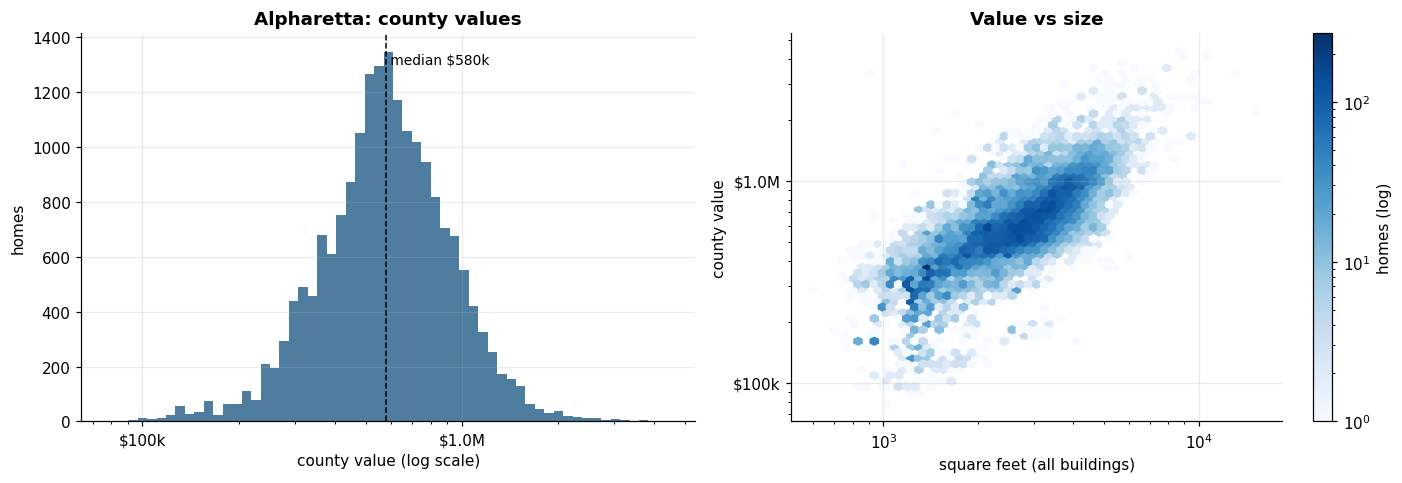

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_value_hist(axes[0], alph['TotAppr'].to_numpy(), 'alpharetta')
axes[0].set_title('Alpharetta: county values')

# bigger house = higher value trend
hb = axes[1].hexbin(alph['AreaSF_all'], alph['TotAppr'], gridsize=55, xscale='log', yscale='log',
                    bins='log', cmap='Blues', mincnt=1)
axes[1].yaxis.set_major_formatter(money)
axes[1].set_xlabel('square feet (all buildings)')
axes[1].set_ylabel('county value')
axes[1].set_title('Value vs size')
plt.colorbar(hb, ax=axes[1], label='homes (log)')
save(fig, 'alph_value_and_sqft')

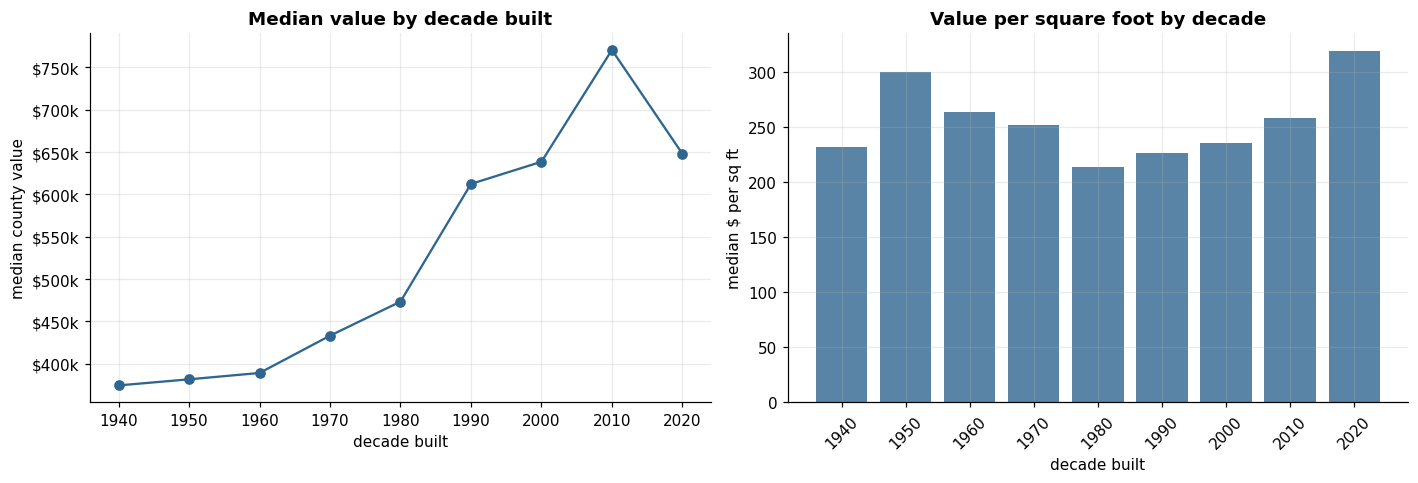

In [41]:
# skip decades with under few homes
decade = alph['YrBlt'] // 10 * 10
by_decade = alph.groupby(decade).agg(median=('TotAppr', 'median'), count=('TotAppr', 'count'),
                                     ppsf=('ppsf', 'median'))
by_decade = by_decade[by_decade['count'] >= 20]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(by_decade.index, by_decade['median'], marker='o', color=COLOR['alpharetta'])
axes[0].yaxis.set_major_formatter(money)
axes[0].set_xlabel('decade built')
axes[0].set_ylabel('median county value')
axes[0].set_title('Median value by decade built')

axes[1].bar(by_decade.index.astype(int).astype(str), by_decade['ppsf'], color=COLOR['alpharetta'], alpha=0.8)
axes[1].set_xlabel('decade built')
axes[1].set_ylabel('median $ per sq ft')
axes[1].set_title('Value per square foot by decade')
axes[1].tick_params(axis='x', rotation=45)
save(fig, 'alph_year_built')

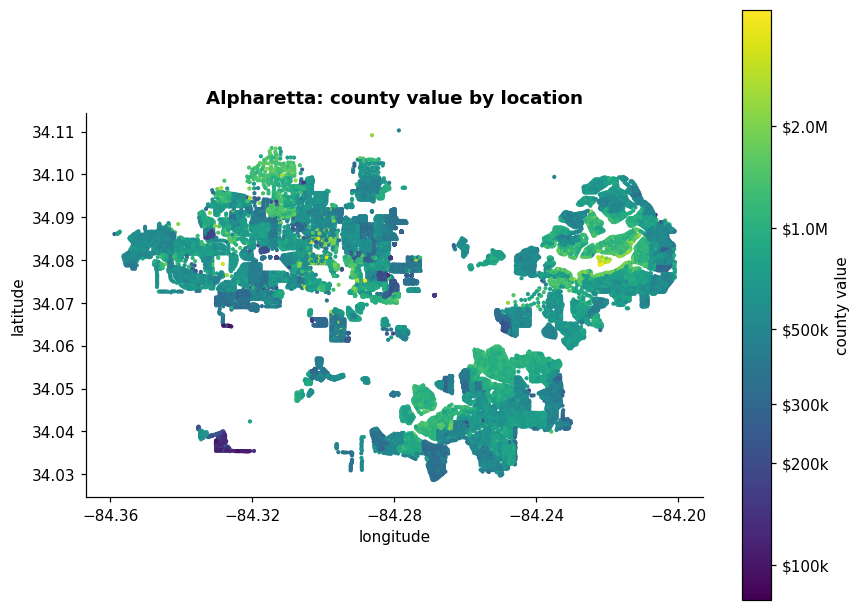

In [42]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_map(ax, alph['lon'].to_numpy(), alph['lat'].to_numpy(), alph['TotAppr'].to_numpy(),
         'Alpharetta: county value by location', 'county value')
save(fig, 'alph_value_map')

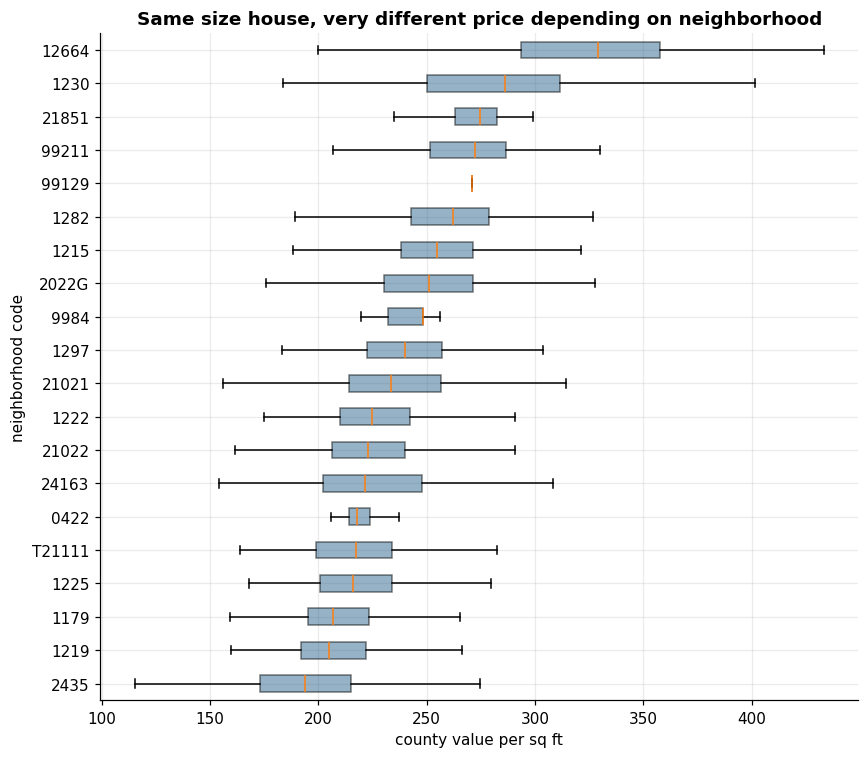

In [43]:
# price/sqft in 20 biggest neighborhoods to see location
top_nbr = alph['NbrHood'].value_counts().head(20).index
order = alph[alph['NbrHood'].isin(top_nbr)].groupby('NbrHood')['ppsf'].median().sort_values().index
data = [alph.loc[alph['NbrHood'] == n, 'ppsf'] for n in order]

fig, ax = plt.subplots(figsize=(8, 7))
ax.boxplot(data, vert=False, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor=COLOR['alpharetta'], alpha=0.5))
ax.set_yticks(range(1, len(order) + 1), order)
ax.set_xlabel('county value per sq ft')
ax.set_ylabel('neighborhood code')
ax.set_title('Same size house, very different price depending on neighborhood')
save(fig, 'alph_ppsf_by_neighborhood')

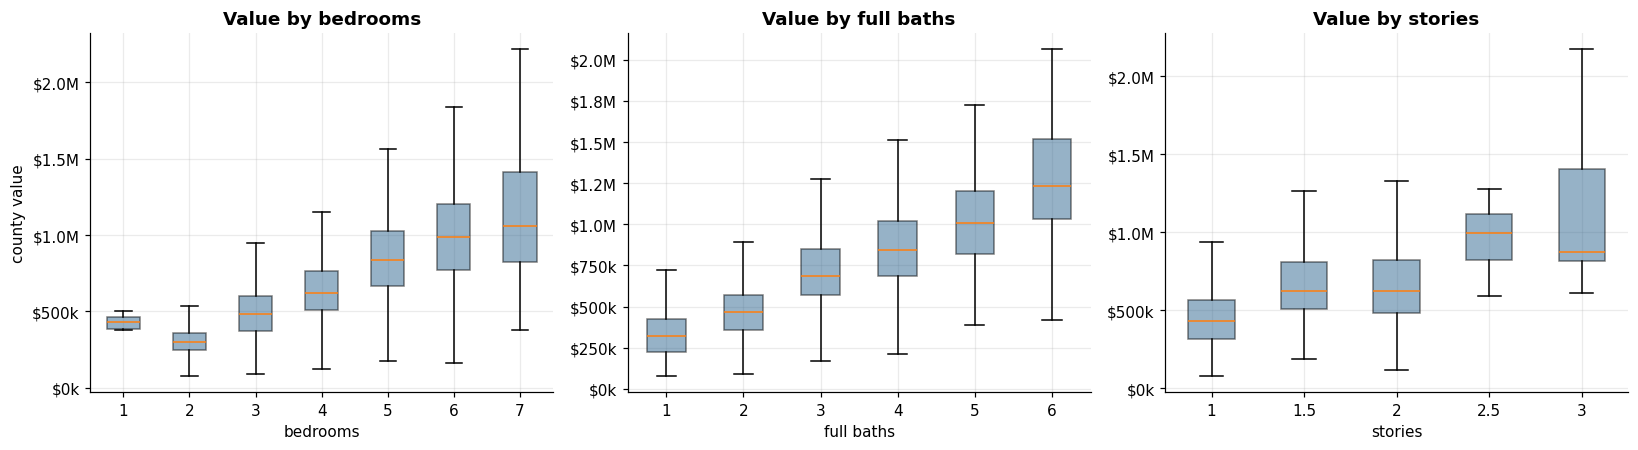

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, label in zip(axes, ['TotBed', 'FixBath', 'Stories'], ['bedrooms', 'full baths', 'stories']):
    # only values with 25+ homes
    counts = alph[col].value_counts()
    keep = sorted(counts[counts >= 25].index)
    data = [alph.loc[alph[col] == k, 'TotAppr'] for k in keep]
    ax.boxplot(data, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor=COLOR['alpharetta'], alpha=0.5))
    ax.set_xticks(range(1, len(keep) + 1), [f'{k:g}' for k in keep])
    ax.yaxis.set_major_formatter(money)
    ax.set_xlabel(label)
    ax.set_title(f'Value by {label}')
axes[0].set_ylabel('county value')
save(fig, 'alph_beds_baths_stories')

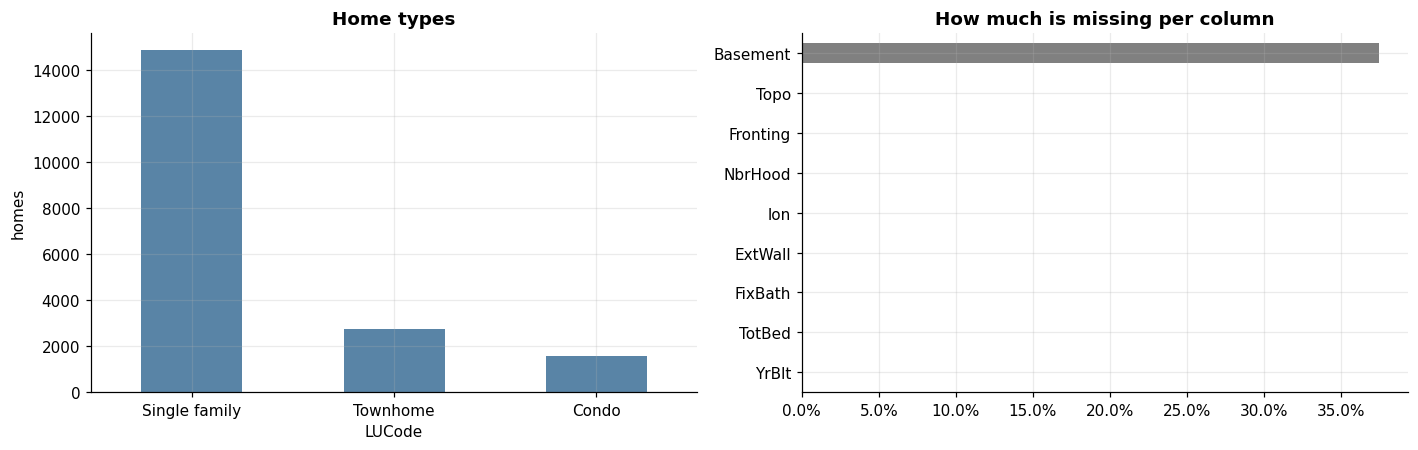

In [45]:
USE_LABELS = {'101': 'Single family', '106': 'Condo', '107': 'Townhome'}
home_type = alph['LUCode'].map(USE_LABELS).fillna('Other')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
home_type.value_counts().plot.bar(ax=axes[0], color=COLOR['alpharetta'], alpha=0.8)
axes[0].set_title('Home types')
axes[0].set_ylabel('homes')
axes[0].tick_params(axis='x', rotation=0)

# % missing per column
check_cols = ['YrBlt', 'TotBed', 'FixBath', 'Basement', 'ExtWall', 'Topo', 'Fronting', 'lon', 'NbrHood']
missing = alph[check_cols].isna().mean().sort_values()
missing.plot.barh(ax=axes[1], color='gray')
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_title('How much is missing per column')
save(fig, 'alph_types_and_missing')

In [46]:
# 3 input sets, each tested 2 ways
BASE = ['LandAcres', 'LivUnits', 'LUCode', 'NbrHood']
BUILDING = ['AreaSF_all', 'YrBlt', 'Stories', 'TotBed', 'FixBath', 'FixHalf', 'TotRooms', 'Basement',
            'FinBsmtVal', 'ExtWall', 'Attic', 'Firepl_S', 'Firepl_PF', 'n_cards', 'Topo', 'Fronting']
A_CATS = ['LUCode', 'NbrHood', 'Basement', 'ExtWall', 'Attic', 'Topo', 'Fronting']
A_FEATURES = BASE + BUILDING + ['lon', 'lat']

y_a = np.log1p(alph['TotAppr'])
actual_a = alph['TotAppr'].to_numpy()

feature_sets = {'A: v1 inputs': BASE,
                'B: + building details': BASE + BUILDING,
                'C: + coordinates': A_FEATURES}
nbr_groups = alph['NbrHood'].fillna('none')

rows = []
for name, cols in feature_sets.items():
    X = make_X(alph, cols, A_CATS)

    # normal 5 fold
    oof = oof_predict(X, y_a, KFold(5, shuffle=True, random_state=42))
    row = {'inputs': name, 'validation': 'random folds'}
    row.update(summarize(np.expm1(oof), actual_a))
    rows.append(row)

    # keep set C so the final model doesnt have to redo it
    if name == 'C: + coordinates':
        oof_a = oof

    # harder test, whole neighborhoods left out
    oof_nbr = oof_predict(X, y_a, GroupKFold(5), nbr_groups)
    row = {'inputs': name, 'validation': 'whole neighborhoods held out'}
    row.update(summarize(np.expm1(oof_nbr), actual_a))
    rows.append(row)
    print('done', name)

alpharetta_compare = pd.DataFrame(rows)
alpharetta_compare

done A: v1 inputs
done B: + building details
done C: + coordinates


,inputs,validation,R2,MAE $,MAPE %,median APE %,within 10% of county value
0,A: v1 inputs,random folds,0.739,78416,11.15,7.25,62.0
1,A: v1 inputs,whole neighborhoods held out,-0.008,222974,39.41,29.19,19.3
2,B: + building details,random folds,0.909,46407,6.45,3.97,80.8
3,B: + building details,whole neighborhoods held out,0.567,138290,20.87,16.34,29.8
4,C: + coordinates,random folds,0.911,45659,6.34,3.93,81.3
5,C: + coordinates,whole neighborhoods held out,0.604,130822,20.32,15.63,31.8


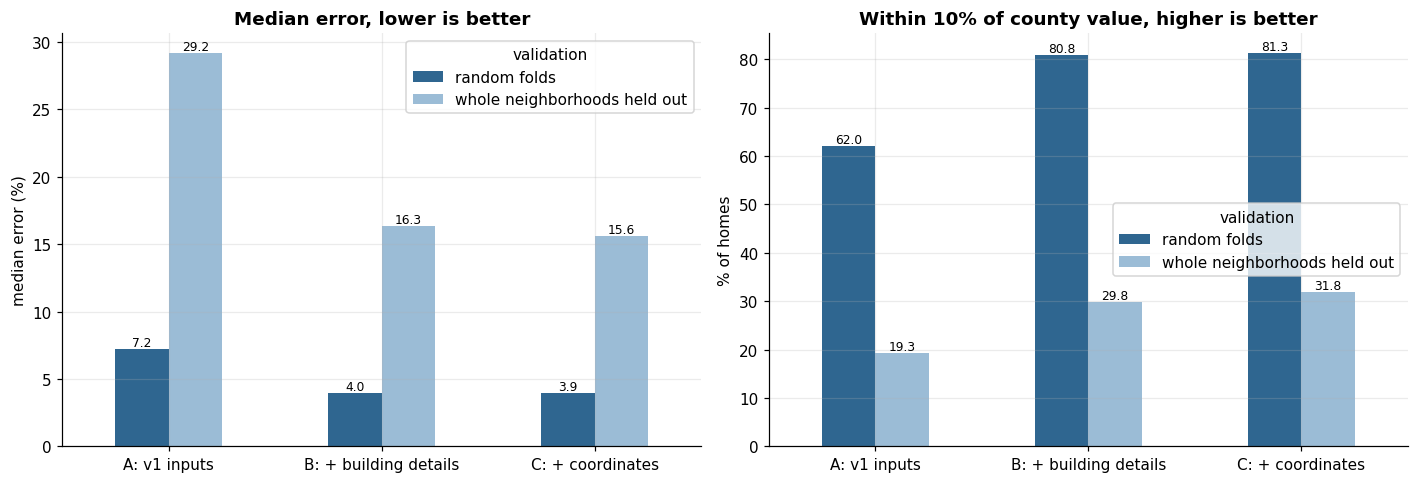

In [47]:
pivot_mape = alpharetta_compare.pivot(index='inputs', columns='validation', values='median APE %')
pivot_hit = alpharetta_compare.pivot(index='inputs', columns='validation', values='within 10% of county value')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pivot_mape.plot.bar(ax=axes[0], color=[COLOR['alpharetta'], '#9bbcd6'], rot=0)
axes[0].set_ylabel('median error (%)')
axes[0].set_title('Median error, lower is better')
pivot_hit.plot.bar(ax=axes[1], color=[COLOR['alpharetta'], '#9bbcd6'], rot=0)
axes[1].set_ylabel('% of homes')
axes[1].set_title('Within 10% of county value, higher is better')
for ax in axes:
    ax.set_xlabel('')
    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.1f', fontsize=8)
save(fig, 'alph_feature_comparison')

In [48]:
#set C
X_a = make_X(alph, A_FEATURES, A_CATS)
resid_a = (y_a - oof_a).to_numpy()
lo_a, hi_a = make_interval(resid_a)

# estimate plus the 80% band
alph['estimate'] = np.expm1(oof_a)
alph['est_low'] = alph['estimate'] * np.exp(lo_a)
alph['est_high'] = alph['estimate'] * np.exp(hi_a)

alpharetta_scores = summarize(alph['estimate'].to_numpy(), actual_a)
alpharetta_coverage = split_half_coverage(resid_a)
alpharetta_tier_cov = coverage_by_tier(actual_a, alph['est_low'].to_numpy(), alph['est_high'].to_numpy())

# one model on all the data
model_a = lgb.LGBMRegressor(**PARAMS)
model_a.fit(X_a, y_a)

print(alpharetta_scores)
print(f'80% band: {np.exp(lo_a) - 1:+.1%} to {np.exp(hi_a) - 1:+.1%}')
print('band coverage on held out half:', alpharetta_coverage)
alpharetta_tier_cov

{'R2': 0.911, 'MAE $': 45659, 'MAPE %': 6.34, 'median APE %': 3.93, 'within 10% of county value': 81.3}
80% band: -8.6% to +10.9%
band coverage on held out half: 0.798


,0
lowest 20%,0.843
20-40%,0.851
40-60%,0.846
60-80%,0.769
top 20%,0.691


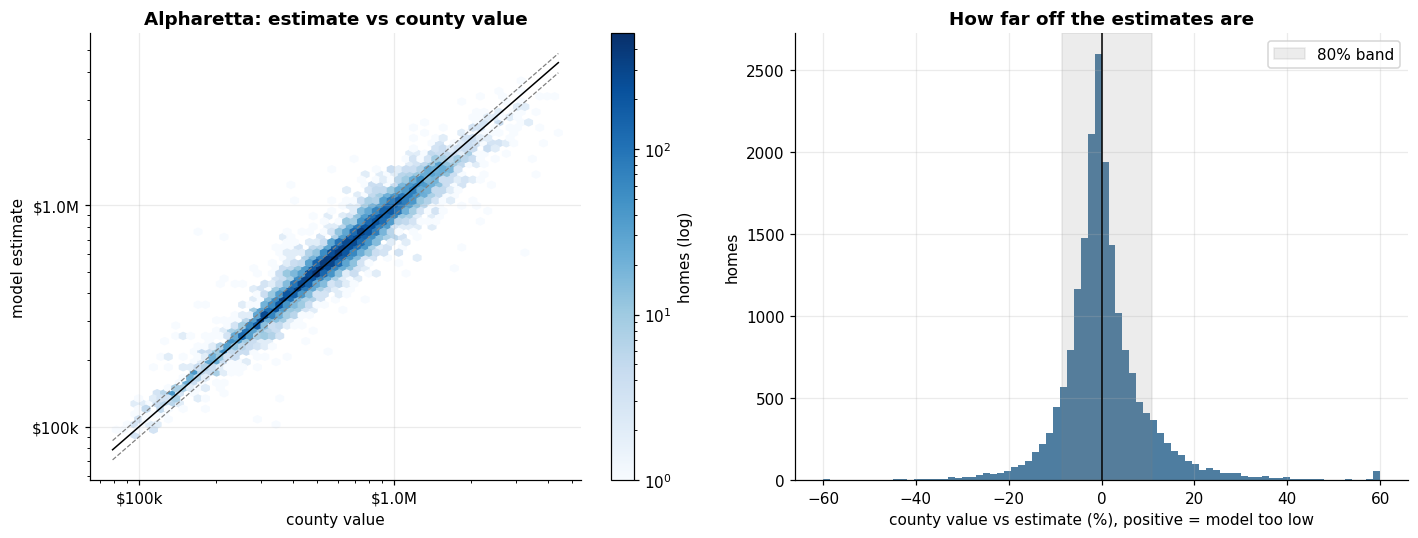

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_pred_vs_actual(axes[0], actual_a, alph['estimate'].to_numpy(), 'alpharetta',
                    'Alpharetta: estimate vs county value')
plot_residuals(axes[1], resid_a, lo_a, hi_a, 'alpharetta')
axes[1].set_title('How far off the estimates are')
save(fig, 'alph_accuracy')

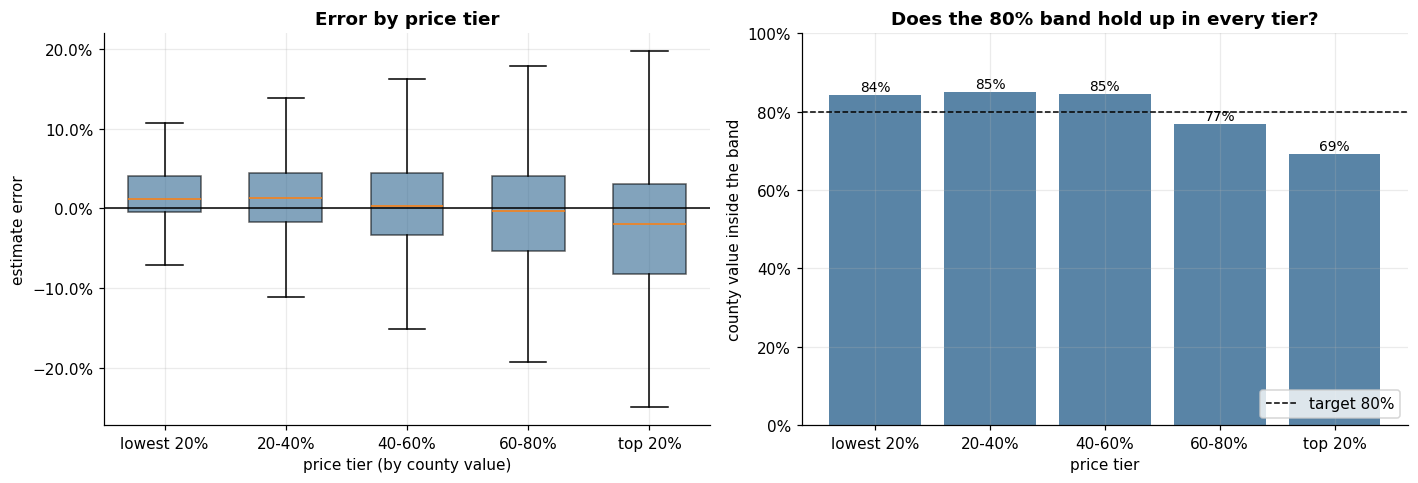

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_error_by_tier(axes[0], actual_a, alph['estimate'].to_numpy(), 'alpharetta')
axes[0].set_title('Error by price tier')
plot_coverage(axes[1], alpharetta_tier_cov, 'alpharetta')
axes[1].set_title('Does the 80% band hold up in every tier?')
save(fig, 'alph_tiers')

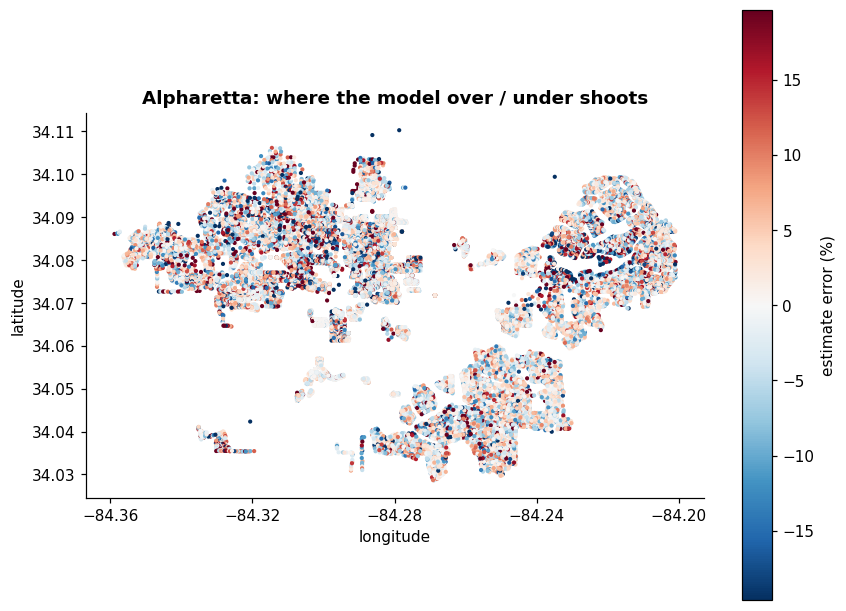

,Address,AreaSF_all,YrBlt,LandAcres,TotAppr,estimate,pct_err
10508,3345 SUGAR VALLEY TRL,4111.0,1996.0,0.3,166000.0,776047.4,367.5
10691,10630 CENTENNIAL DR,3706.0,2024.0,0.3,212400.0,704249.7,231.6
5130,1060 BAY POINTE CROSSING,5015.0,1995.0,0.6,402560.0,1218643.8,202.7
1428,204 BROOK DR,4603.0,2024.0,0.4,561200.0,1476338.8,163.1
4193,372 KAREN DR,6168.0,2024.0,0.4,416200.0,1058903.6,154.4
9082,620 FLYING SCOT WAY,4166.0,1985.0,0.5,706300.0,1618303.3,129.1
300,1480 MID BROADWELL RD,1282.0,1960.0,1.5,217600.0,478752.7,120.0
4183,315 KAREN DR,1176.0,1965.0,0.4,205000.0,447239.9,118.2
4006,378 BRADY PL,1140.0,1940.0,0.2,135400.0,285740.1,111.0
4487,175 KIMBALL BRIDGE RD,768.0,1949.0,1.2,172400.0,358922.6,108.2


In [51]:
# red = model too high, blue = too low
alph['pct_err'] = (alph['estimate'] - alph['TotAppr']) / alph['TotAppr'] * 100

fig, ax = plt.subplots(figsize=(8, 7))
plot_map(ax, alph['lon'].to_numpy(), alph['lat'].to_numpy(), alph['pct_err'].to_numpy(),
         'Alpharetta: where the model over / under shoots', 'estimate error (%)', diverging=True)
save(fig, 'alph_error_map')

# 10 worst misses
worst = alph.loc[alph['pct_err'].abs().sort_values(ascending=False).index[:10]]
worst[['Address', 'AreaSF_all', 'YrBlt', 'LandAcres', 'TotAppr', 'estimate', 'pct_err']].round(1)

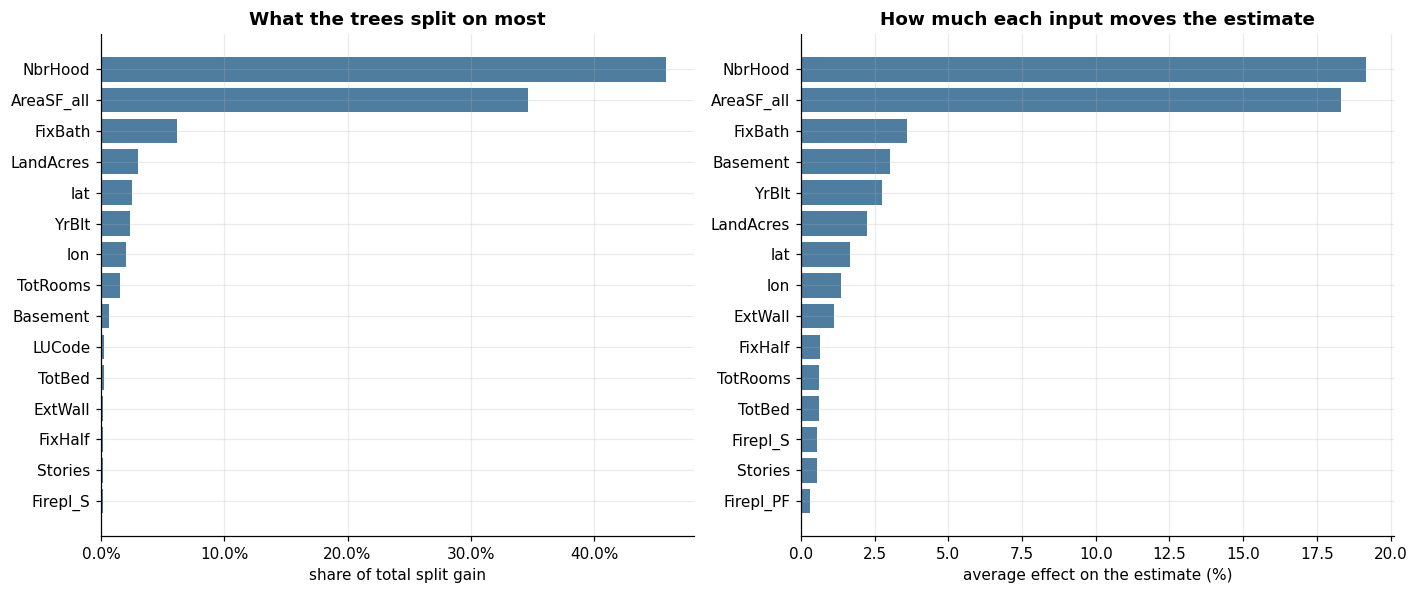

In [52]:
contrib_a = contributions(model_a, X_a)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_importance(axes[0], model_a, 'alpharetta')
axes[0].set_title('What the trees split on most')
plot_mean_contrib(axes[1], contrib_a, 'alpharetta')
axes[1].set_title('How much each input moves the estimate')
save(fig, 'alph_importance')

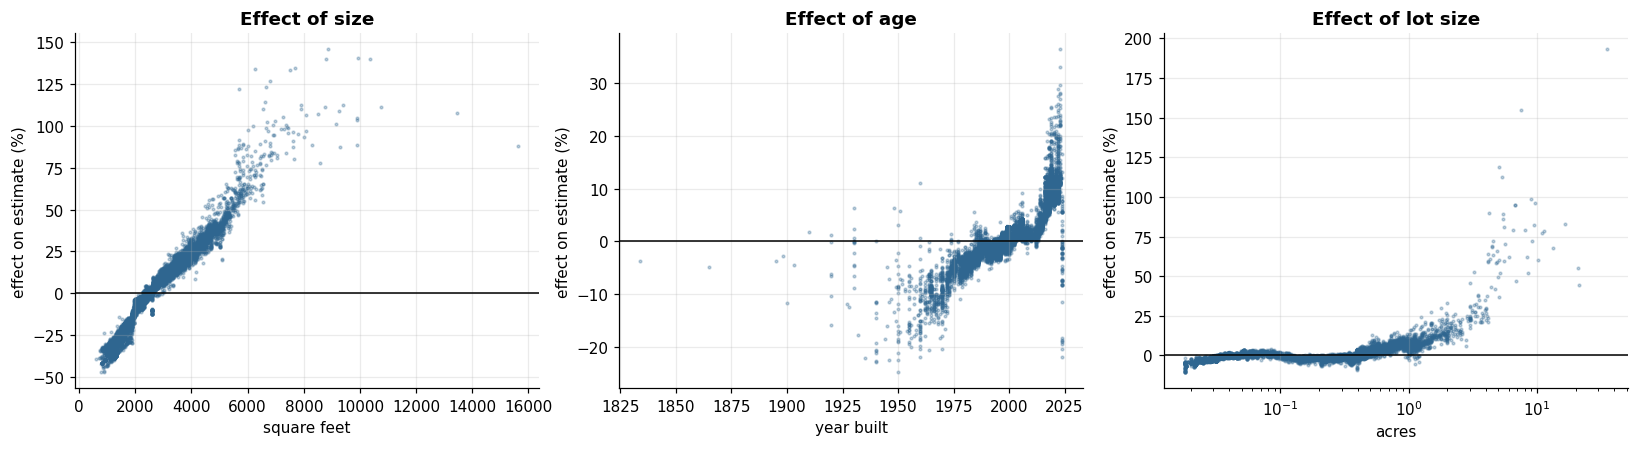

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plot_dependence(axes[0], alph['AreaSF_all'], contrib_a['AreaSF_all'], 'alpharetta', 'square feet')
axes[0].set_title('Effect of size')
plot_dependence(axes[1], alph['YrBlt'], contrib_a['YrBlt'], 'alpharetta', 'year built')
axes[1].set_title('Effect of age')
plot_dependence(axes[2], alph['LandAcres'], contrib_a['LandAcres'], 'alpharetta', 'acres')
axes[2].set_xscale('log')
axes[2].set_title('Effect of lot size')
save(fig, 'alph_dependence')

In [54]:
# county value isnt the sale price so check both against real sales
sales = pd.read_csv(DATA_DIR / 'alpharetta_sales.csv', dtype=str)
sales['ParcelID'] = sales['ParcelID'].str.strip()
sales['date'] = pd.to_datetime(sales['SaleDate'], errors='coerce')
sales['price'] = pd.to_numeric(sales['Price'], errors='coerce')

# normal sales only, warranty deed + land and building + over 100k
normal = (sales['InstrType'].fillna('').str.contains('Warranty')
          & (sales['SaleType'] == 'Land & Building')
          & (sales['price'] >= 100_000))
arms = sales[normal].dropna(subset=['date']).sort_values('date')
print(f'{len(sales):,} sales, {len(arms):,} normal ones')

# last sale for each home
last_sale = arms.drop_duplicates('ParcelID', keep='last').set_index('ParcelID')[['date', 'price']]
last_sale.columns = ['last_sale_date', 'last_sale_price']
alph = alph.drop(columns=['last_sale_date', 'last_sale_price'], errors='ignore')
alph = alph.merge(last_sale, left_on='ParcelID', right_index=True, how='left')

# homes that sold in each year
SALE_YEARS = [2023, 2024, 2025]
sold = {}
for year in SALE_YEARS:
    s = arms[arms['date'].dt.year == year].drop_duplicates('ParcelID', keep='last')
    sold[year] = alph.merge(s[['ParcelID', 'price']], on='ParcelID')


# COD = avg distance from the median ratio
def sale_check(d):
    out = {'sales used': len(d)}
    for label, col in [('county value', 'TotAppr'), ('model estimate', 'estimate')]:
        ratio = d[col] / d['price']
        med = ratio.median()
        out[label + ' / sale price (median)'] = round(float(med), 3)
        out[label + ' spread (COD %)'] = round(float((ratio - med).abs().mean() / med * 100), 1)
    return out


sales_check = pd.DataFrame({year: sale_check(sold[year]) for year in SALE_YEARS})
sales_check

77,693 sales, 18,494 normal ones


,2023,2024,2025
sales used,10.000,160.000,308.000
county value / sale price (median),0.970,0.859,0.786
county value spread (COD %),19.400,15.700,21.400
model estimate / sale price (median),0.923,0.853,0.780
model estimate spread (COD %),19.900,14.300,22.000


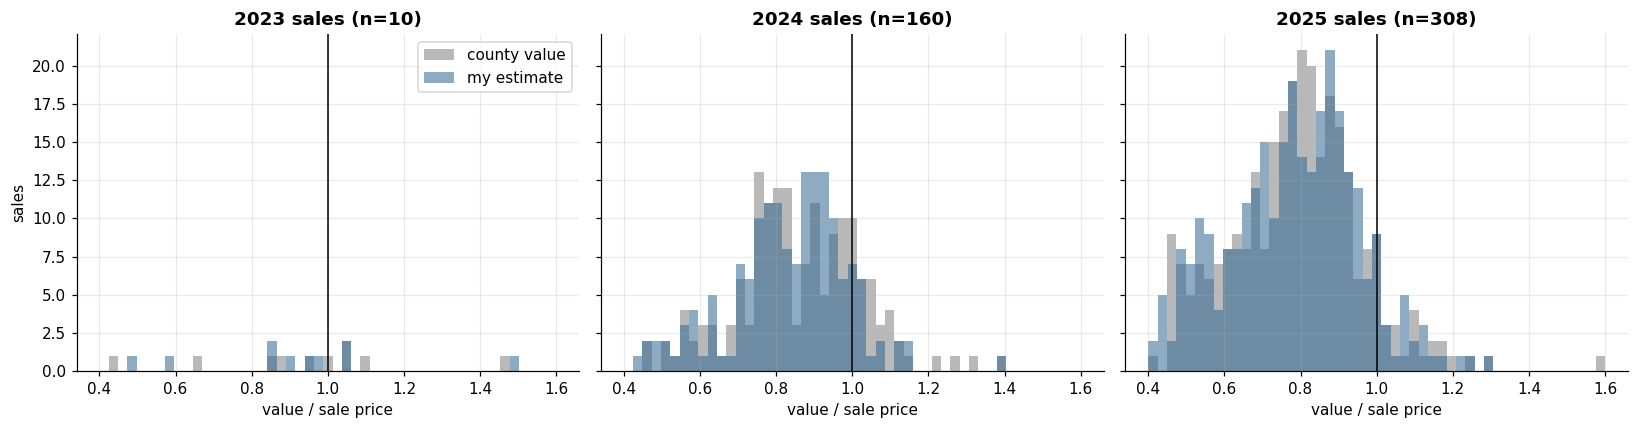

In [55]:
fig, axes = plt.subplots(1, len(SALE_YEARS), figsize=(15, 4), sharey=True)
bins = np.linspace(0.4, 1.6, 50)
for ax, year in zip(axes, SALE_YEARS):
    d = sold[year]
    if len(d) == 0:
        ax.set_title(f'{year}: no sales')
        continue
    ax.hist(d['TotAppr'] / d['price'], bins=bins, alpha=0.55, color='gray', label='county value')
    ax.hist(d['estimate'] / d['price'], bins=bins, alpha=0.55, color=COLOR['alpharetta'], label='my estimate')
    ax.axvline(1, color='black', lw=1)
    ax.set_title(f'{year} sales (n={len(d):,})')
    ax.set_xlabel('value / sale price')
axes[0].set_ylabel('sales')
axes[0].legend()
save(fig, 'alph_sales_ratio')

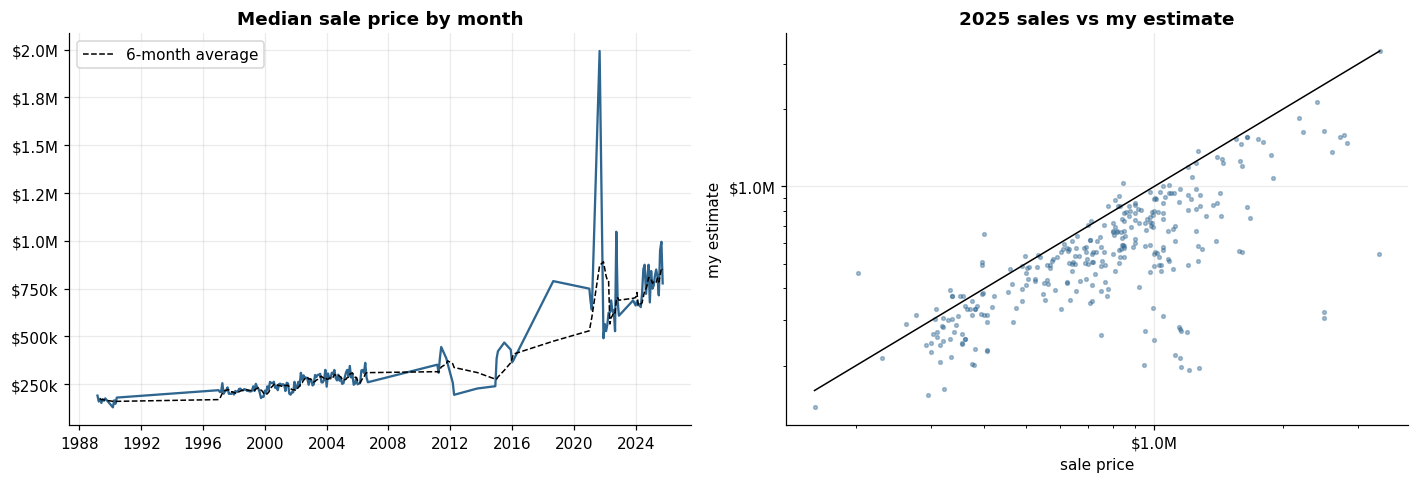

In [56]:
# median sale price per month
monthly = arms.set_index('date')['price'].resample('MS').agg(['median', 'count'])
# skip months with under 5 sales
monthly = monthly[monthly['count'] >= 5]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(monthly.index, monthly['median'], color=COLOR['alpharetta'], lw=1.5)
axes[0].plot(monthly.index, monthly['median'].rolling(6, min_periods=3).mean(), color='black', lw=1, ls='--',
             label='6-month average')
axes[0].yaxis.set_major_formatter(money)
axes[0].set_title('Median sale price by month')
axes[0].legend()

recent = sold[SALE_YEARS[-1]]
if len(recent) > 0:
    axes[1].scatter(recent['price'], recent['estimate'], s=6, alpha=0.4, color=COLOR['alpharetta'])
    lim = [recent['price'].min(), recent['price'].max()]
    axes[1].plot(lim, lim, color='black', lw=1)
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].xaxis.set_major_formatter(money)
    axes[1].yaxis.set_major_formatter(money)
    axes[1].set_xlabel('sale price')
    axes[1].set_ylabel('my estimate')
    axes[1].set_title(f'{SALE_YEARS[-1]} sales vs my estimate')
save(fig, 'alph_sales_trend')

In [57]:
# forsyth is one file
fo = pd.read_csv(DATA_DIR / 'forsyth_parcels.csv',
                 dtype={'PARCELID': str, 'NGHBRHDCD': str, 'USECD': str, 'CLASSCD': str, 'ZONING': str,
                        'STRCLASS': str, 'RESSTRTYP': str})
fo['PARCELID'] = fo['PARCELID'].str.strip()
n0 = len(fo)

# homes with a building and a value
fo = fo[fo['BLDGAREA'].fillna(0) > 0]
fo = fo[fo['RESFLRAREA'] != 0]
fo = fo[fo['CNTASSDVAL'] > 0]

# some ids show up twice so keep bigger building
fo = fo.sort_values('BLDGAREA', ascending=False).drop_duplicates('PARCELID').reset_index(drop=True)

# year built 0 = unknown
fo['RESYRBLT'] = fo['RESYRBLT'].where(fo['RESYRBLT'] > 1800)
fo['home_age'] = 2025 - fo['RESYRBLT']
fo['owns_lot'] = (fo['STATEDAREA'] > 0).astype(int)

print(f'forsyth: {n0:,} -> {len(fo):,} after cleaning')
print('unknown year built:', fo['RESYRBLT'].isna().sum())
fo[['SITEADDRESS', 'BLDGAREA', 'home_age', 'STATEDAREA', 'CNTASSDVAL']].head()

forsyth: 85,556 -> 80,306 after cleaning
unknown year built: 1


,SITEADDRESS,BLDGAREA,home_age,STATEDAREA,CNTASSDVAL
0,7855 BETHEL RD,14707.0,21.0,4.00,3884740.0
1,3345 CHIMNEY POINT DR,13468.0,41.0,0.72,3685200.0
2,8430 ST MARLO COUNTRY CLUB PKWY,12545.0,0.0,1.82,1178870.0
3,2610 HERMITAGE DR,12005.0,15.0,1.60,4055220.0
4,6410 HOLLAND DR,11900.0,99.0,10.76,6716440.0


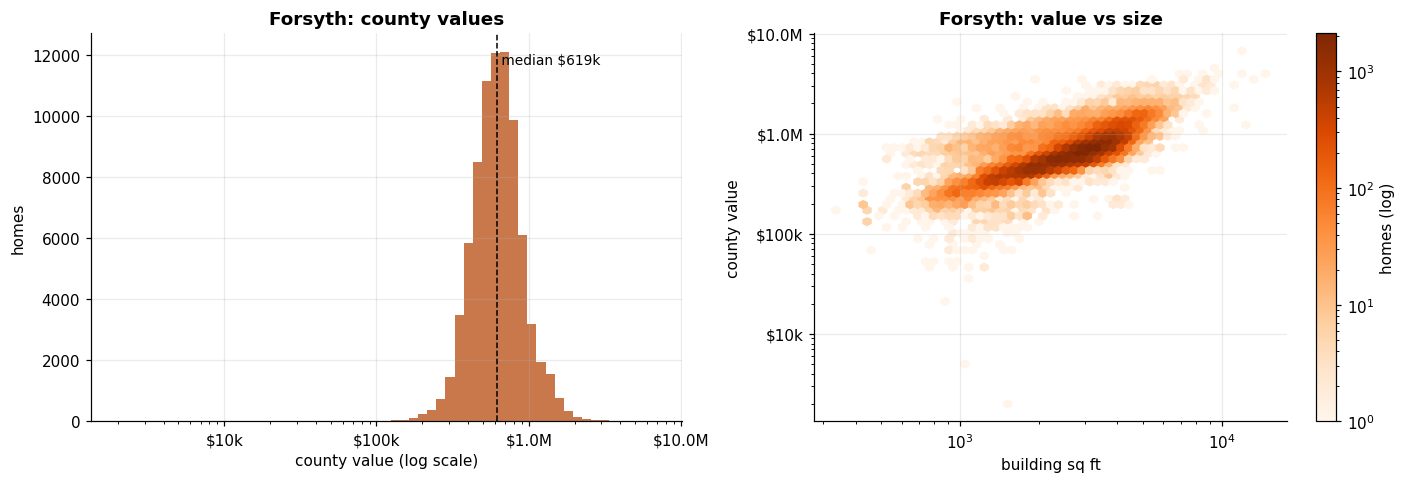

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_value_hist(axes[0], fo['CNTASSDVAL'].to_numpy(), 'forsyth')
axes[0].set_title('Forsyth: county values')

hb = axes[1].hexbin(fo['BLDGAREA'], fo['CNTASSDVAL'], gridsize=55, xscale='log', yscale='log',
                    bins='log', cmap='Oranges', mincnt=1)
axes[1].yaxis.set_major_formatter(money)
axes[1].set_xlabel('building sq ft')
axes[1].set_ylabel('county value')
axes[1].set_title('Forsyth: value vs size')
plt.colorbar(hb, ax=axes[1], label='homes (log)')
save(fig, 'fors_value_and_sqft')

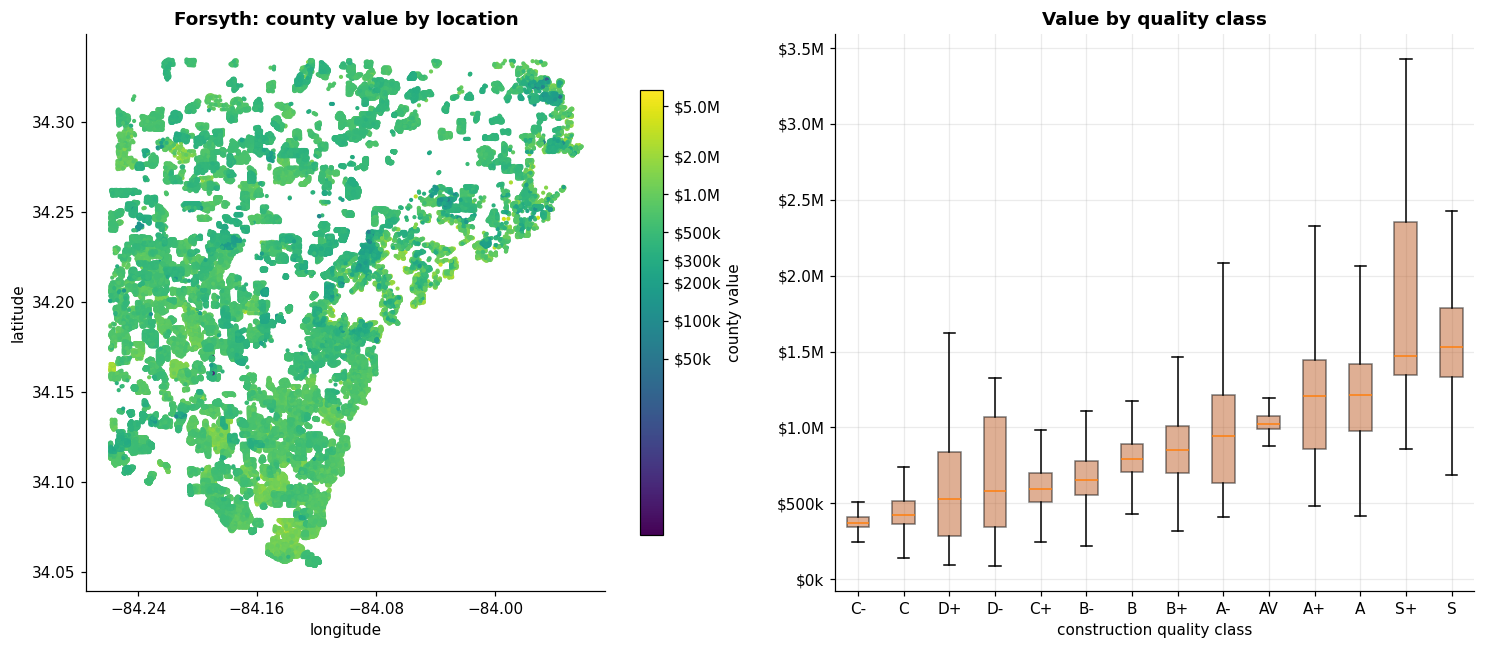

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.1, 1]})
plot_map(axes[0], fo['lon'].to_numpy(), fo['lat'].to_numpy(), fo['CNTASSDVAL'].to_numpy(),
         'Forsyth: county value by location', 'county value')

# quality classes with 25+ homes sorted by median value
counts = fo['STRCLASS'].value_counts()
keep = counts[counts >= 25].index
order = fo[fo['STRCLASS'].isin(keep)].groupby('STRCLASS')['CNTASSDVAL'].median().sort_values().index
data = [fo.loc[fo['STRCLASS'] == k, 'CNTASSDVAL'] for k in order]
axes[1].boxplot(data, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor=COLOR['forsyth'], alpha=0.5))
axes[1].set_xticks(range(1, len(order) + 1), order)
axes[1].yaxis.set_major_formatter(money)
axes[1].set_xlabel('construction quality class')
axes[1].set_title('Value by quality class')
save(fig, 'fors_map_and_quality')

In [60]:
F_CATS_V1 = ['USECD', 'NGHBRHDCD', 'CLASSCD', 'ZONING']
F_V1 = ['BLDGAREA', 'RESFLRAREA', 'home_age', 'FLOORCOUNT', 'STATEDAREA', 'LNDVALUE', 'owns_lot'] + F_CATS_V1
F_CATS = F_CATS_V1 + ['STRCLASS', 'RESSTRTYP']

# land value is the countys own number and the web app wont have it
f_no_land = [c for c in F_V1 if c != 'LNDVALUE']
F_FEATURES = f_no_land + ['STRCLASS', 'RESSTRTYP', 'lon', 'lat']

y_f = np.log1p(fo['CNTASSDVAL'])
actual_f = fo['CNTASSDVAL'].to_numpy()

f_sets = {'v1 inputs (with land value)': F_V1,
          'minus land value': f_no_land,
          '+ quality and structure type': f_no_land + ['STRCLASS', 'RESSTRTYP'],
          '+ coordinates': F_FEATURES}

rows = []
for name, cols in f_sets.items():
    X = make_X(fo, cols, F_CATS)
    oof = oof_predict(X, y_f, KFold(5, shuffle=True, random_state=42))
    row = {'inputs': name}
    row.update(summarize(np.expm1(oof), actual_f))
    rows.append(row)
    # last set=final model
    if name == '+ coordinates':
        oof_f = oof
    print('done', name)

forsyth_compare = pd.DataFrame(rows)
forsyth_compare

done v1 inputs (with land value)
done minus land value
done + quality and structure type
done + coordinates


,inputs,R2,MAE $,MAPE %,median APE %,within 10% of county value
0,v1 inputs (with land value),0.928,43070,6.51,4.34,82.4
1,minus land value,0.906,46643,7.04,4.50,80.8
2,+ quality and structure type,0.909,45869,6.84,4.45,81.3
3,+ coordinates,0.912,45380,6.76,4.42,81.6


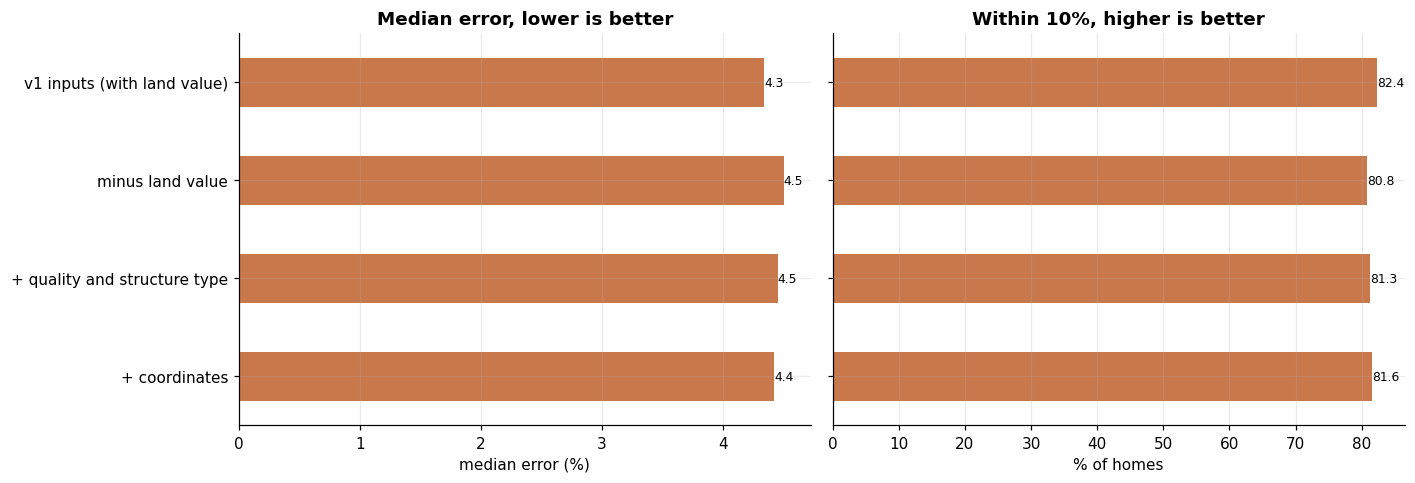

In [61]:
fc = forsyth_compare.set_index('inputs')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fc['median APE %'].plot.barh(ax=axes[0], color=COLOR['forsyth'], alpha=0.85)
axes[0].set_xlabel('median error (%)')
axes[0].set_title('Median error, lower is better')
fc['within 10% of county value'].plot.barh(ax=axes[1], color=COLOR['forsyth'], alpha=0.85)
axes[1].set_xlabel('% of homes')
axes[1].set_title('Within 10%, higher is better')
axes[1].set_yticklabels([])
for ax in axes:
    ax.set_ylabel('')
    ax.invert_yaxis()
    ax.bar_label(ax.containers[0], fmt='%.1f', fontsize=8)
save(fig, 'fors_feature_comparison')

In [62]:
# oof_f is from the comparison cell
X_f = make_X(fo, F_FEATURES, F_CATS)
resid_f = (y_f - oof_f).to_numpy()
lo_f, hi_f = make_interval(resid_f)

fo['estimate'] = np.expm1(oof_f)
fo['est_low'] = fo['estimate'] * np.exp(lo_f)
fo['est_high'] = fo['estimate'] * np.exp(hi_f)

forsyth_scores = summarize(fo['estimate'].to_numpy(), actual_f)
forsyth_coverage = split_half_coverage(resid_f)
forsyth_tier_cov = coverage_by_tier(actual_f, fo['est_low'].to_numpy(), fo['est_high'].to_numpy())

model_f = lgb.LGBMRegressor(**PARAMS)
model_f.fit(X_f, y_f)

print(forsyth_scores)
print(f'80% band: {np.exp(lo_f) - 1:+.1%} to {np.exp(hi_f) - 1:+.1%}')
print('band coverage on held out half:', forsyth_coverage)
forsyth_tier_cov

{'R2': 0.912, 'MAE $': 45380, 'MAPE %': 6.76, 'median APE %': 4.42, 'within 10% of county value': 81.6}
80% band: -8.5% to +11.0%
band coverage on held out half: 0.8


,0
lowest 20%,0.800
20-40%,0.876
40-60%,0.845
60-80%,0.794
top 20%,0.685


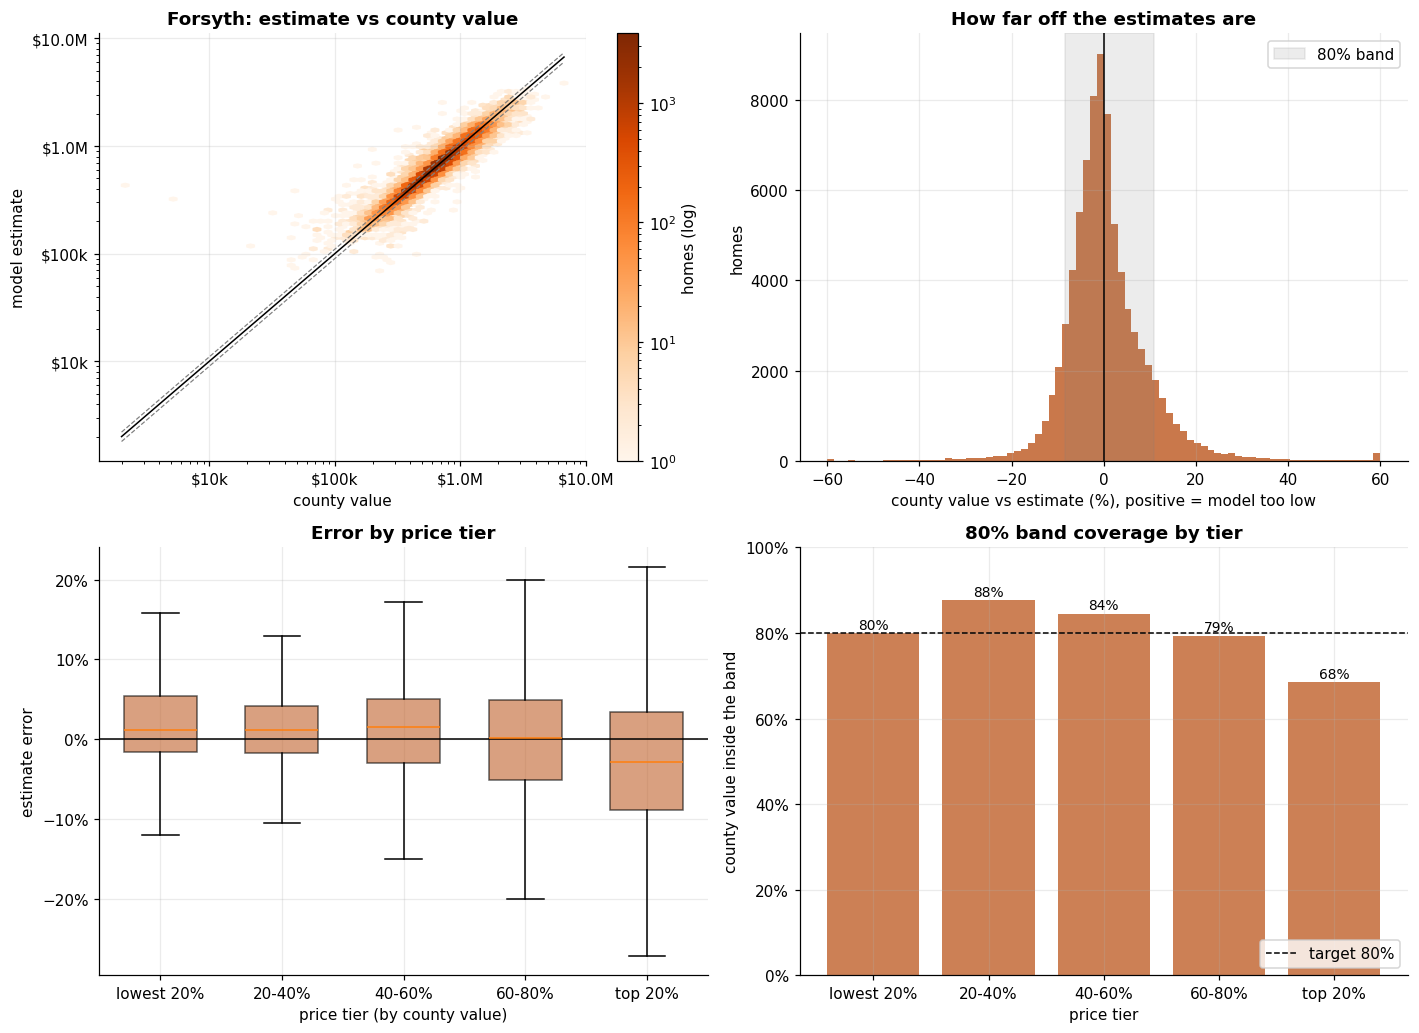

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
plot_pred_vs_actual(axes[0, 0], actual_f, fo['estimate'].to_numpy(), 'forsyth', 'Forsyth: estimate vs county value')
plot_residuals(axes[0, 1], resid_f, lo_f, hi_f, 'forsyth')
axes[0, 1].set_title('How far off the estimates are')
plot_error_by_tier(axes[1, 0], actual_f, fo['estimate'].to_numpy(), 'forsyth')
axes[1, 0].set_title('Error by price tier')
plot_coverage(axes[1, 1], forsyth_tier_cov, 'forsyth')
axes[1, 1].set_title('80% band coverage by tier')
save(fig, 'fors_accuracy')

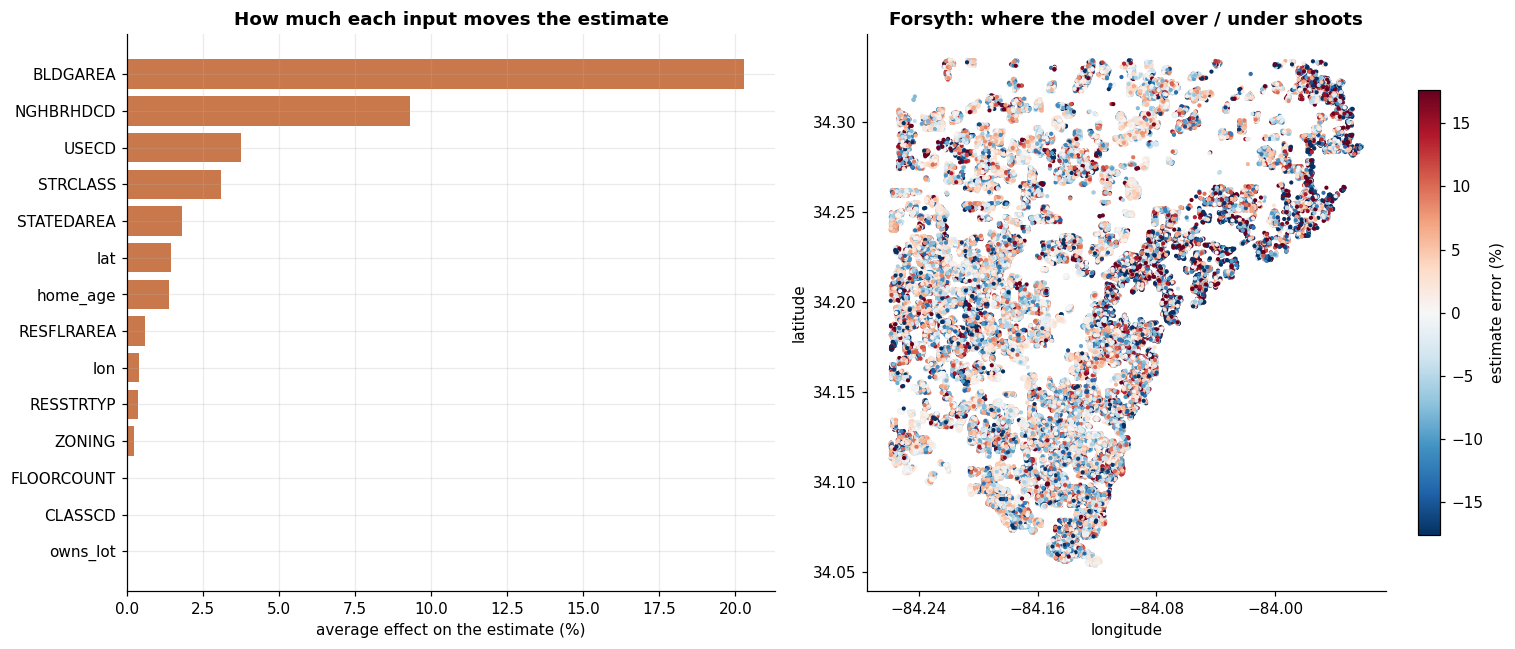

In [64]:
contrib_f = contributions(model_f, X_f)
fo['pct_err'] = (fo['estimate'] - fo['CNTASSDVAL']) / fo['CNTASSDVAL'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_mean_contrib(axes[0], contrib_f, 'forsyth')
axes[0].set_title('How much each input moves the estimate')
plot_map(axes[1], fo['lon'].to_numpy(), fo['lat'].to_numpy(), fo['pct_err'].to_numpy(),
         'Forsyth: where the model over / under shoots', 'estimate error (%)', diverging=True)
save(fig, 'fors_importance_and_error_map')

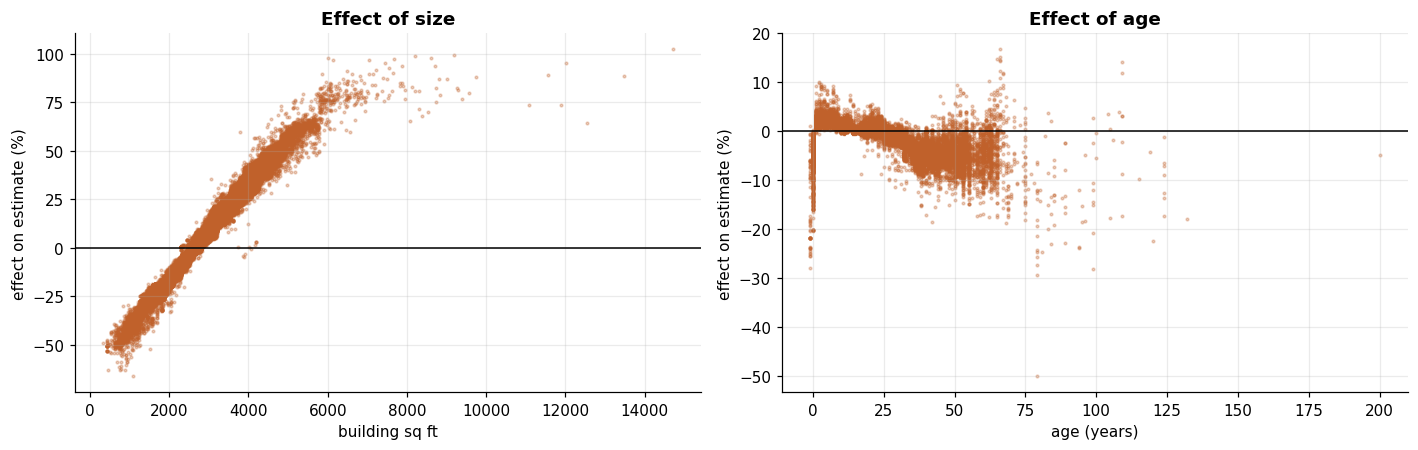

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_dependence(axes[0], fo['BLDGAREA'], contrib_f['BLDGAREA'], 'forsyth', 'building sq ft')
axes[0].set_title('Effect of size')
plot_dependence(axes[1], fo['home_age'], contrib_f['home_age'], 'forsyth', 'age (years)')
axes[1].set_title('Effect of age')
save(fig, 'fors_dependence')

,R2,MAE $,MAPE %,median APE %,within 10% of county value,band coverage %
Alpharetta,0.911,45659.0,6.34,3.93,81.3,79.8
Forsyth,0.912,45380.0,6.76,4.42,81.6,80.0


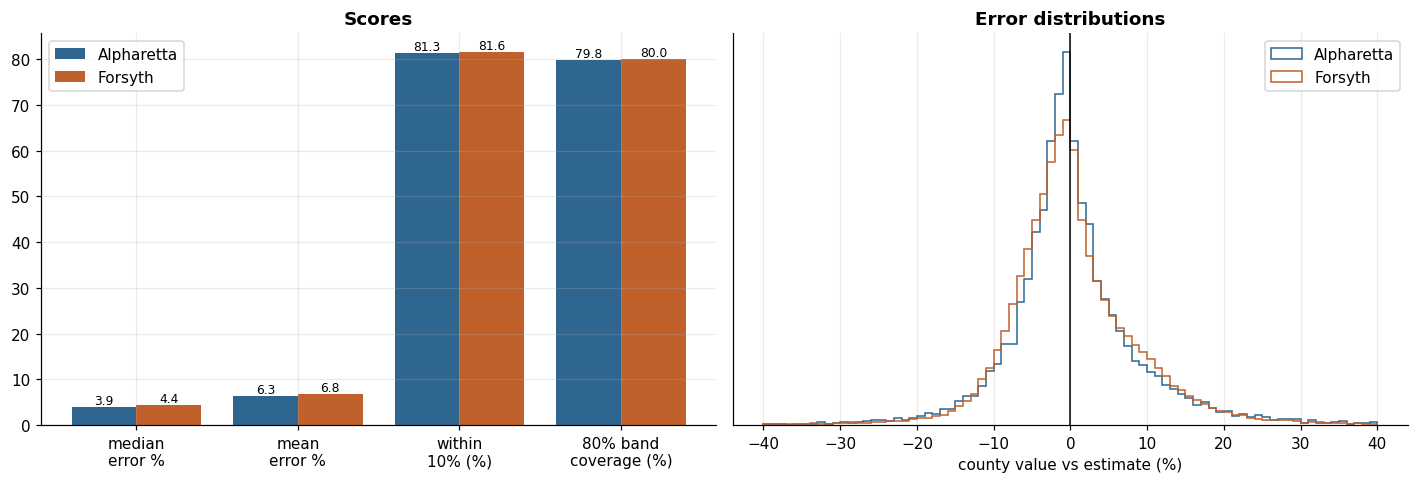

In [66]:
# both counties side by side
both = pd.DataFrame({'Alpharetta': alpharetta_scores, 'Forsyth': forsyth_scores}).T
both['band coverage %'] = [alpharetta_coverage * 100, forsyth_coverage * 100]
display(both)

show = ['median APE %', 'MAPE %', 'within 10% of county value', 'band coverage %']
x = np.arange(len(show))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(x - 0.2, both.loc['Alpharetta', show], 0.4, color=COLOR['alpharetta'], label='Alpharetta')
axes[0].bar(x + 0.2, both.loc['Forsyth', show], 0.4, color=COLOR['forsyth'], label='Forsyth')
axes[0].set_xticks(x, ['median\nerror %', 'mean\nerror %', 'within\n10% (%)', '80% band\ncoverage (%)'])
axes[0].legend()
axes[0].set_title('Scores')
for bars in axes[0].containers:
    axes[0].bar_label(bars, fmt='%.1f', fontsize=8)

bins = np.linspace(-40, 40, 81)
axes[1].hist((np.exp(resid_a) - 1) * 100, bins=bins, density=True, histtype='step', lw=2,
             color=COLOR['alpharetta'], label='Alpharetta')
axes[1].hist((np.exp(resid_f) - 1) * 100, bins=bins, density=True, histtype='step', lw=2,
             color=COLOR['forsyth'], label='Forsyth')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('county value vs estimate (%)')
axes[1].set_yticks([])
axes[1].set_title('Error distributions')
axes[1].legend()
save(fig, 'both_markets')

In [67]:
# one row per home for the web app, estimates rounded to $100
a_out = pd.DataFrame({
    'market': 'alpharetta', 'parcel_id': alph['ParcelID'], 'address': alph['Address'],
    'lon': alph['lon'].round(6), 'lat': alph['lat'].round(6), 'tax_year': alph['TaxYear'],
    'use': alph['LUCode'].map(USE_LABELS), 'neighborhood': alph['NbrHood'], 'subdivision': alph['Subdiv'],
    'acres': alph['LandAcres'], 'sqft': alph['AreaSF_all'], 'year_built': alph['YrBlt'], 'floors': alph['Stories'],
    'beds': alph['TotBed'], 'baths': alph['FixBath'], 'half_baths': alph['FixHalf'],
    'county_value': alph['TotAppr'], 'estimate': alph['estimate'], 'est_low': alph['est_low'],
    'est_high': alph['est_high'], 'last_sale_date': alph['last_sale_date'].dt.date,
    'last_sale_price': alph['last_sale_price'], 'county_link': ''})

# forsyth has no beds/baths or sales
f_out = pd.DataFrame({
    'market': 'forsyth', 'parcel_id': fo['PARCELID'], 'address': fo['SITEADDRESS'],
    'lon': fo['lon'].round(6), 'lat': fo['lat'].round(6), 'tax_year': fo['TAXYEAR'],
    'use': fo['USEDSCRP'], 'neighborhood': fo['NGHBRHDCD'], 'subdivision': fo['CNVYNAME'],
    'acres': fo['STATEDAREA'], 'sqft': fo['BLDGAREA'], 'year_built': fo['RESYRBLT'], 'floors': fo['FLOORCOUNT'],
    'beds': np.nan, 'baths': np.nan, 'half_baths': np.nan,
    'county_value': fo['CNTASSDVAL'], 'estimate': fo['estimate'], 'est_low': fo['est_low'],
    'est_high': fo['est_high'], 'last_sale_date': pd.NaT, 'last_sale_price': np.nan,
    'county_link': fo['Link']})

for out, name in [(a_out, 'alpharetta_v2.csv'), (f_out, 'forsyth_v2.csv')]:
    for c in ['estimate', 'est_low', 'est_high']:
        out[c] = out[c].round(-2).astype(int)
    out.to_csv(OUT_DIR / name, index=False)
    print(name, out.shape)

alpharetta_v2.csv (19218, 23)
forsyth_v2.csv (80306, 23)


In [68]:
# all the scores in one json
a_final = {'features': A_FEATURES}
a_final.update(alpharetta_scores)
a_final.update({'band_coverage': alpharetta_coverage, 'band_log_low': lo_a, 'band_log_high': hi_a,
                'coverage_by_tier': alpharetta_tier_cov.to_dict()})

f_final = {'features': F_FEATURES}
f_final.update(forsyth_scores)
f_final.update({'band_coverage': forsyth_coverage, 'band_log_low': lo_f, 'band_log_high': hi_f,
                'coverage_by_tier': forsyth_tier_cov.to_dict()})

# json keys have to be strings
sale_json = {}
for year, vals in sales_check.to_dict().items():
    sale_json[str(year)] = vals

metrics = {'rows': {'alpharetta': len(alph), 'forsyth': len(fo)},
           'alpharetta_compare': alpharetta_compare.to_dict('records'),
           'alpharetta_final': a_final,
           'alpharetta_sales_check': sale_json,
           'forsyth_compare': forsyth_compare.to_dict('records'),
           'forsyth_final': f_final,
           'params': PARAMS}

with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2, default=str)

# save the models already fit above
model_a.booster_.save_model(str(OUT_DIR / 'alpharetta_model.txt'))
model_f.booster_.save_model(str(OUT_DIR / 'forsyth_model.txt'))

print('saved to', OUT_DIR)
print(sorted(p.name for p in OUT_DIR.iterdir()))
print(len(list(FIG_DIR.glob('*.png'))), 'charts')

saved to /content/drive/MyDrive/housing_price_project_v2/output
['alpharetta_model.txt', 'alpharetta_v2.csv', 'figures', 'forsyth_model.txt', 'forsyth_v2.csv', 'metrics.json']
21 charts
